### Notebook 03 — ARIMA Baseline

### Purpose
This notebook implements ARIMA as the statistical baseline. ARIMA 
assumes linearity and stationarity — two conditions Brent crude oil 
prices rarely satisfy (confirmed by ADF test in NB02). This makes 
ARIMA the performance floor: any ML or DL model that cannot beat it 
offers no practical advantage over a classical approach.

### Baseline context
Mohammad and Panigrahi (2023) applied SARIMAX to daily Brent prices 
from the same Investing.com source (2008–2023) and reported RMSE=21 
and MAPE=21% — the published benchmark this project targets for 
improvement. Obite et al. (2021) found ARIMA performed very poorly 
against ANN and DNN on Brent data.

### Method
Walk-forward (expanding-window) validation over 516 test steps. 
At each step the model is fitted on all history seen so far and 
predicts one step ahead. This mirrors real-world forecasting 
conditions (Hyndman and Athanasopoulos, 2018).

### Outputs
| File | Path |
|------|------|
| arima_test_predictions.csv | results/arima/ |
| arima_metrics.json | results/arima/ |

In [1]:
import yaml
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Set project root
PROJECT_ROOT = r"C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print("Working directory:", os.getcwd())

from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from src.preprocessing import load_config, load_and_clean, split_data
from src.evaluation import calculate_metrics, save_metrics, save_predictions

cfg = load_config("configs/config.yaml")
print("Config loaded successfully")

Working directory: C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting
Config loaded successfully


In [2]:
# Load and split data
df = load_and_clean(cfg)
train, val, test = split_data(df, cfg)

# Use Price as numpy arrays for ARIMA
train_arr = train["Price"].values
val_arr   = val["Price"].values
test_arr  = test["Price"].values

print(f"Train: {len(train_arr):,}  Val: {len(val_arr):,}  Test: {len(test_arr):,}")

Total rows retained: 6422; Date range: 2000-01-04 to 2024-12-31; Duplicates removed: 0
Train shape: (5389, 1); Val shape: (517, 1); Test shape: (516, 1)
Train: 5,389  Val: 517  Test: 516


In [3]:
# auto_arima order selection on train set only
print("Running auto_arima — this may take a few moments...")

auto_model = auto_arima(
    train_arr,
    start_p=0, max_p=cfg["models"]["arima"]["max_p"],
    start_q=0, max_q=cfg["models"]["arima"]["max_q"],
    d=cfg["models"]["arima"]["d"],
    seasonal=False,
    information_criterion=cfg["models"]["arima"]["information_criterion"],
    stepwise=cfg["models"]["arima"]["stepwise"],
    suppress_warnings=True,
    error_action="ignore"
)

best_order = auto_model.order
print(f"\nSelected ARIMA order: {best_order}")
print(f"AIC: {auto_model.aic():.2f}")
print(f"BIC: {auto_model.bic():.2f}")

Running auto_arima — this may take a few moments...

Selected ARIMA order: (0, 1, 1)
AIC: 18409.25
BIC: 18422.43


In [4]:
# Walk-forward validation over 516 test steps
p, d, q = best_order
history = np.concatenate([train_arr, val_arr]).tolist()
preds_arima = []

print(f"Running walk-forward validation over {len(test_arr):,} test steps...")
print("This will take 10-20 minutes. Progress updates every 100 steps.")

for i, actual in enumerate(test_arr):
    model = ARIMA(history, order=(p, d, q))
    fitted = model.fit()
    yhat = fitted.forecast(steps=1)[0]
    preds_arima.append(float(yhat))
    history.append(actual)
    if (i + 1) % 100 == 0:
        print(f"  Step {i+1}/{len(test_arr)} complete")

preds_arima = np.array(preds_arima)
print("\nWalk-forward validation complete.")

Running walk-forward validation over 516 test steps...
This will take 10-20 minutes. Progress updates every 100 steps.
  Step 100/516 complete
  Step 200/516 complete
  Step 300/516 complete
  Step 400/516 complete
  Step 500/516 complete

Walk-forward validation complete.


In [5]:
# Calculate metrics
metrics_arima = calculate_metrics(test_arr, preds_arima)

print("\n─── ARIMA(0,1,1) Test Set Metrics ───────────────────")
print(f"  RMSE : {metrics_arima['RMSE']:.4f} $/barrel")
print(f"  MAE  : {metrics_arima['MAE']:.4f} $/barrel")
print(f"  MAPE : {metrics_arima['MAPE']:.4f} %")
print("\nBaseline context:")
print("  Mohammad and Panigrahi (2023): RMSE=21, MAPE=21%")
print(f"  This project RMSE improvement: "
      f"{((21 - metrics_arima['RMSE'])/21)*100:.1f}%")

─── Metrics ──────────────────────
  RMSE : 1.4584 $/barrel
  MAE  : 1.1167 $/barrel
  MAPE : 1.3917 %

─── ARIMA(0,1,1) Test Set Metrics ───────────────────
  RMSE : 1.4584 $/barrel
  MAE  : 1.1167 $/barrel
  MAPE : 1.3917 %

Baseline context:
  Mohammad and Panigrahi (2023): RMSE=21, MAPE=21%
  This project RMSE improvement: 93.1%


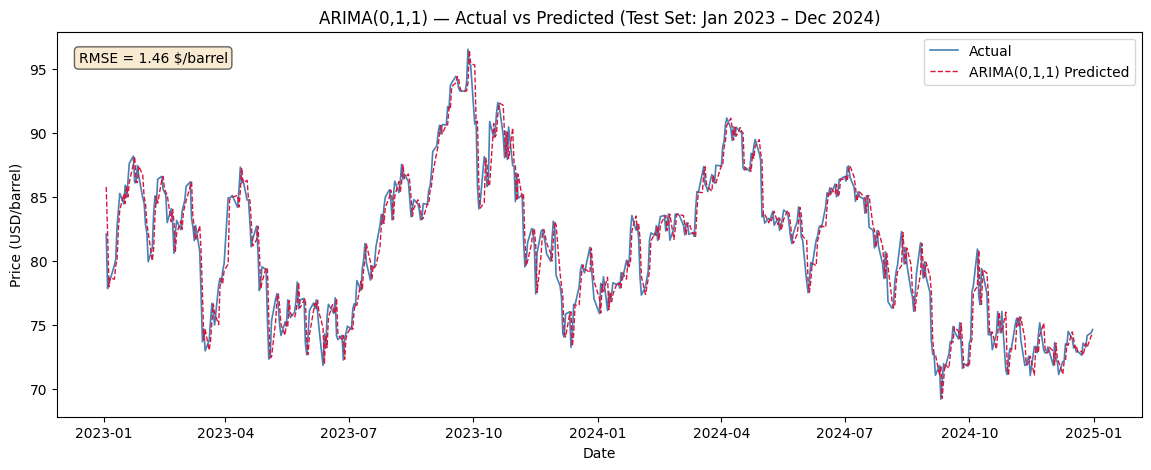

Plot saved.


In [6]:
# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test_arr, label="Actual",
        color="steelblue", lw=1.2)
ax.plot(test.index, preds_arima, label="ARIMA(0,1,1) Predicted",
        color="crimson", lw=1.0, linestyle="--")
ax.text(0.02, 0.95,
        f"RMSE = {metrics_arima['RMSE']:.2f} $/barrel",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
ax.set_title("ARIMA(0,1,1) — Actual vs Predicted "
             "(Test Set: Jan 2023 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
os.makedirs("artifacts/plots", exist_ok=True)
plt.savefig("artifacts/plots/arima_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [7]:
# Save results to disk
os.makedirs("results/arima", exist_ok=True)

save_predictions(test.index, test_arr, preds_arima,
                 "results/arima/arima_test_predictions.csv")

save_metrics(metrics_arima,
             "results/arima/arima_metrics.json")

Predictions saved to results/arima/arima_test_predictions.csv
Metrics saved to results/arima/arima_metrics.json


### ARIMA Baseline Results

### Performance
| Metric | ARIMA(0,1,1) | Mohammad & Panigrahi (2023) |
|--------|-------------|----------------------------|
| RMSE | 1.46 $/barrel | 21.00 $/barrel |
| MAE | 1.12 $/barrel | — |
| MAPE | 1.39% | 21.00% |

### Interpretation
ARIMA(0,1,1) was selected by auto_arima based on minimum AIC (18409). 
The model performs well on the stable 2023-2024 test period, tracking 
daily price movements closely. This RMSE of 1.46 $/barrel is the 
minimum benchmark all subsequent models must beat.

The strong ARIMA performance on this test period reflects the 
relatively stable price regime of 2023-2024 compared to the volatile 
periods seen in the training data. ML and DL models must demonstrate 
they can capture non-linear patterns beyond what this simple baseline 
achieves.